# Análisis Exploratorio y Feature Engineering — Detección de Fraude Federado
### Datasets Bancos: BO VIP, BR PRIVADO, GT ESTATAL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")


In [2]:
DATA_DIR = r"Copia de Datasets 3 bancos"
FILES = {
    "BO_VIP":    os.path.join(DATA_DIR, "Copia de 01_bo_vip_seed22_n100000.csv"),
    "BR_PRIVATE": os.path.join(DATA_DIR, "Copia de 02_br_privado_seed33_n100000.csv"),
    "GT_STATE":  os.path.join(DATA_DIR, "Copia de 03_gt_estatal_seed3_n100000.csv"),
}

---
## Carga de Datos

In [8]:
dfs_raw = {}
for name, path in FILES.items():
    df = pd.read_csv(path, sep=";", low_memory=False)
    df["source_bank"] = name
    dfs_raw[name] = df
    print(f"[{name}] shape: {df.shape}\n  - is_fraud nulos: {df['is_fraud'].isna().sum()}")



[BO_VIP] shape: (100003, 67)
  - is_fraud nulos: 0
[BR_PRIVATE] shape: (100000, 67)
  - is_fraud nulos: 0
[GT_STATE] shape: (100000, 67)
  - is_fraud nulos: 100000


In [7]:
#transacciones duplicadas 
bo = dfs_raw["BO_VIP"]
br = dfs_raw["BR_PRIVATE"]
gt = dfs_raw["GT_STATE"]
print(bo['transaction_id'].duplicated().sum())
print(br['transaction_id'].duplicated().sum())
print(gt['transaction_id'].duplicated().sum())

0
0
0


In [10]:
bo

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,source_bank
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,e253ee7d060689e75077b0c7d85d995bf4ba104a7a931e...,100,5312700000000000.0000,0,39379,345082,101000151,87630970.0000,947249,200151,1231,2901,101.0000,5651,826,72,1.0000,0,14484680068,531270******3773=2901201,TEBBJIQJPQP9,17P76V,0,BO-23325,M74178102540833,LEVIS STORE LONDON GB,NaN,NaN,826,68,68,N,NaN,N,NaN,14484680068.0000,POS-ATTENDED,0.0000,BO-VIP,14484680068.0000,ACC774404459020,NaN,07200N,3450.8200,393.7900,GBP,500.1200,True,8717.0000,20,Tue,True,Approved,2012.5100,TARIJA,False,BO_VIP
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,9de2ffd889d660bc1d350aff8143484eaab5246c0c3f31...,100,4212500000000000.0000,0,1310264,1310264,101000355,10000000.0000,7687,200355,1231,2907,101.0000,4511,68,81,2.0000,59,14484680068,421250******5552=2907201,115BVLO5H5F0,48D1XM,0,BO-34705,M95802681578714,IBERIA LAPAZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC620405269742,NaN,08159N,13102.6400,13102.6400,BOB,1898.9300,False,4.9000,20,Tue,True,Approved,1096.4600,LAPAZ,False,BO_VIP
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,14d38149e4bcdeffed96229129ba6d359b477780d24ba0...,100,5312700000000000.0000,0,241394,241394,101000410,10000000.0000,979481,200410,1231,2610,101.0000,5732,68,81,2.0000,59,14484680068,531270******6104=2610201,NUKM3XFSZVJX,PFIGFD,0,BO-31334,M28333044130009,AMAZON ELECTRO SANTACRUZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC606260684104,NaN,08159N,2413.9400,2413.9400,BOB,349.8500,False,4.4000,20,Tue,True,Approved,1528.3700,SANTACRUZ,False,BO_VIP
3,3a836c25-7a8c-473b-8141-3e84ba3f212d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002587,PLATINUM,ATM,VISA,479500******0288,7ff3ca034215fd90c2019b8762e9493cc5867dff207082...,100,4795000000000000.0000,10000,31416,238449,101000453,75900496.0000,915846,200453,1231,2710,101.0000,6011,250,51,2.0000,0,14484680068,479500******0288=2710201,BF4EW9A6R844,7Z9YO7,0,BO-65992,M76079092139715,ATM RED LINK PARIS FR,NaN,NaN,978,68,68,Y,NaN,Y,NaN,14484680068.0000,ATM-UNATTENDED,0.0000,BO-VIP,14484680068.0000,ACC743423920527,NaN,05100Y,2384.4900,314.1600,EUR,345.5800,True,3966.0000,20,Tue,True,Approved,2483.3400,SUCRE,False,BO_VIP
4,be9956da-924f-4c68-aed8-f0c5d949e577,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000087,PRIVATE,POS,VISA,479500******0249,bdc9c9f8a47332f4833214c4f90e7a1b88b606d52aec00...,100,4795000000000000.0000,0,82038,82038,101000756,10000000.0000,943975,200756,1231,3004,101.0000,5812,68,21,3.0

In [11]:
br

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,source_bank
0,49b290bb-4479-4367-950d-ed7d9bdc96d0,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00003011,CLASICA,POS,VISA,422355******4250,cde43f85cf5ec9d005e8a539bc2e540a442e43af7a5577...,100,4223550000000000.0000,0,7461,7461,101000221,10000000.0000,749972,210221,1231,2705,101.0000,7832,76,51,1.0000,0,8881828076,422355******4250=2705201,VVYLJQRDBRFS,H1M3X7,0,BR-26205,M75866946948952,CINEPOLIS CURITIBA BR,NaN,NaN,986,986,986,Y,NaN,Y,NaN,8881828076.0000,POS-ATTENDED,0.0000,BR-PRI,8881828076.0000,ACC762765677939,NaN,05100Y,74.6100,74.6100,BRL,14.9200,False,12.1000,21,Tue,True,Approved,714.7400,CURITIBA,False,BR_PRIVATE
1,0697c7b6-b5ab-4ab5-8684-4f3fcdd54ff2,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00000292,ORO,POS,VISA,422355******2908,b1a76140549f19c2367462d823e0d2d1897c53e3968b9e...,100,4223560000000000.0000,0,29162,29162,101000350,10000000.0000,751009,210350,1231,2902,101.0000,5541,76,51,2.0000,0,8881828076,422355******2908=2902201,GTZXO46J719F,74NLNC,0,BR-89263,M59412977990756,AXION ENERGY CURITIBA BR,NaN,NaN,986,986,986,Y,NaN,Y,NaN,8881828076.0000,POS-ATTENDED,0.0000,BR-PRI,8881828076.0000,ACC091899892764,NaN,05100Y,291.6200,291.6200,BRL,58.3200,False,2.1000,21,Tue,True,Approved,640.6700,CURITIBA,False,BR_PRIVATE
2,ac73c4c0-ca7d-48b8-ad18-ab6dcc48819c,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00002993,CLASICA,ATM,MASTERCARD,541333******2878,c5f1cc61d76ee0c47fca1b4bab64fa773df3cbf9e00dfe...,100,5413340000000000.0000,10000,24950,24950,101000533,10000000.0000,693786,210533,1231,2610,101.0000,6011,76,51,1.0000,0,8881828076,541333******2878=2610201,T34VRBQVFD68,FCXJ98,0,BR-41537,M81505175379755,ATM SANTANDER BELOHORIZONTEBR,NaN,NaN,986,986,986,Y,NaN,Y,NaN,8881828076.0000,ATM-UNATTENDED,0.0000,BR-PRI,8881828076.0000,ACC796431724778,NaN,05100Y,249.5000,249.5000,BRL,49.9000,False,1086.0000,21,Tue,True,Approved,626.3200,RECIFE,False,BR_PRIVATE
3,b0e4e6d3-9b43-44c8-8fd2-37598de9aaad,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00002693,CLASICA,ATM,VISA,422355******0490,6bb430c9ad26e0913273db4937ac84d6eea46bc34e851a...,100,4223560000000000.0000,10000,20485,20485,101001208,10000000.0000,733323,211208,1231,2807,101.0000,6011,76,51,2.0000,0,8881828076,422355******0490=2807201,8HOW117XS4KW,BFE8F0,0,BR-95461,M46180970941225,ATM RED LINK RIODEJANEIRO BR,NaN,NaN,986,986,986,Y,NaN,Y,NaN,8881828076.0000,ATM-UNATTENDED,0.0000,BR-PRI,8881828076.0000,ACC887592491481,NaN,05100Y,204.8500,204.8500,BRL,40.9700,False,22.6000,21,Tue,True,Approved,278.1900,RIODEJANEIRO,False,BR_PRIVATE
4,557549be-eed1-476d-8a1d-f6a2ae02518f,BR-PRI,BR-PRI,BR,privado,BR-PRI-CL-00000045,PLATINO,POS,MASTERCARD,533421******0731,3cbd84e1c03ebaec7a4a1a98e0f4f693470e49aaa0eea6...,100,5334220000000000.0000,0,7160,35801,101001602,50001396.0000,759060,211602,1

In [12]:
gt

,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,source_bank
0,06a94162-7bae-427c-b68c-2819181b5467,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004881,PLAN_SUELDO,ECOM,VISA,455920******5983,a92f98f97cd8ede91a0dac2dbca2d975e18caf1a2fd444...,100,4559210000000000.0000,0,3788,3788,101000628,10000000.0000,275463,180628,1231,2807,101.0000,5999,320,81,1.0000,59,8112932320,455920******5983=2807201,DUIPJ286IBQD,NZD1VT,0,GT-31817,M53092173939721,VARIEDADES MIX ANTIGUA GT,NaN,NaN,320,320,320,N,NaN,N,NaN,8112932320.0000,ECOM-VIRTUAL,59.0000,GT-EST,8112932320.0000,ACC847762387971,NaN,08159N,37.8800,37.8800,GTQ,4.8600,False,NaN,18,Tue,True,Approved,164.8400,ANTIGUA,NaN,GT_STATE
1,8d261988-07bd-4696-8fe3-ba3526142d2e,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00000966,PLAN_SUELDO,ECOM,VISA,455920******6807,7be1dc2c38ca824693fa11ee4aac7b12ad8f80828b1abd...,100,4559210000000000.0000,0,10092,10092,101000846,10000000.0000,274477,180846,1231,2805,101.0000,4816,320,81,2.0000,59,8112932320,455920******6807=2805201,9CNQS9I18BAW,YFZS5V,0,GT-29794,M53901707180973,VPN PREMIUM ANTIGUA GT,NaN,NaN,320,320,320,N,NaN,N,NaN,8112932320.0000,ECOM-VIRTUAL,59.0000,GT-EST,8112932320.0000,ACC089928841642,NaN,08159N,100.9200,100.9200,GTQ,12.9400,False,8.0000,18,Tue,True,Approved,222.4400,ANTIGUA,NaN,GT_STATE
2,b6be7a48-12fc-40ac-a12f-e2e03637231b,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00004217,PLAN_SUELDO,POS,VISA,492421******9765,63a13a42dab28e218219585a0dc2f1d393b9b464235e1d...,100,4924210000000000.0000,0,1474,1474,101001257,10000000.0000,290652,181257,1231,2705,101.0000,7832,320,21,3.0000,0,8112932320,492421******9765=2705201,UFJFI8UTAELD,IR3HCT,0,GT-90879,M83171026368737,HOYTS CINEMA VILLANUEVA GT,NaN,NaN,320,320,320,Y,NaN,N,NaN,8112932320.0000,POS-ATTENDED,0.0000,GT-EST,8112932320.0000,ACC083114000052,NaN,02100Y,14.7400,14.7400,GTQ,1.8900,False,1.7000,18,Tue,True,Approved,156.7700,VILLANUEVA,NaN,GT_STATE
3,12d06acb-2241-4d57-bfe2-ebb13750d301,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00001115,PLAN_SUELDO,ATM,VISA,492421******3609,b2f8d2e1b8b54189106741ed1303d231131521ff31416a...,100,4924210000000000.0000,10000,6132,6132,101001259,10000000.0000,280506,181259,1231,2709,101.0000,6011,320,51,1.0000,0,8112932320,492421******3609=2709201,LB1IIN8KYND5,FK00G7,0,GT-96293,M72981131617843,ATM HSBC VILLANUEVA GT,NaN,NaN,320,320,320,Y,NaN,Y,NaN,8112932320.0000,ATM-UNATTENDED,0.0000,GT-EST,8112932320.0000,ACC357298244128,NaN,05100Y,61.3200,61.3200,GTQ,7.8600,False,8.2000,18,Tue,True,Approved,92.0700,VILLANUEVA,NaN,GT_STATE
4,5ce8b673-fe15-41e1-bacf-91569a3cbe53,GT-EST,GT-EST,GT,estatal,GT-EST-CL-00002868,PLAN_SUELDO,ECOM,MASTERCARD,548221******8352,67ad25fd61b95791ce83951fca3ab1f78003a6773b3f93...,100,5482210000000000.0000,0,13979,13979,101001322,10000000.0000,316598,181322,1231,2705,101.0000,5

Todos los registros de GT Estatal no tienen la etiquieta **is_fraud**. Tengo 2 opciones, usar GT como test o como dataset final al que le tengo que determinar si es fraudo o no.

In [25]:
df_train = pd.concat([dfs_raw["BO_VIP"], dfs_raw["BR_PRIVATE"]], ignore_index=True)
df_test  = dfs_raw["GT_STATE"].copy()

print(f"Train shape (BO y BR):  {df_train.shape}")
print(f"Test shape (GT):        {df_test.shape}")


Train shape (BO y BR):  (200003, 67)
Test shape (GT):        (100000, 67)


In [ ]:
print("Porcentaje de fraude por banco en train:")
print(df_train.groupby("source_bank")["is_fraud"].mean().map("{:.2%}".format))

Porcentaje de fraude por banco en train:
source_bank
BO_VIP        4.92%
BR_PRIVATE    3.21%
Name: is_fraud, dtype: str


#### Inspección y Análisis de Nulos

In [29]:
print("--- Tipos de datos ---")
print(df_train.dtypes.value_counts())
df_train.head(3)

--- Tipos de datos ---
str        29
int64      19
float64    16
bool        3
Name: count, dtype: int64


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,DE22_pos_entry_mode,DE23_card_seq_number,DE25_pos_condition_code,DE32_acquiring_institution_id,DE35_track2_data_masked,DE37_retrieval_reference_number,DE38_authorization_code,DE39_response_code,DE41_terminal_id,DE42_card_acceptor_id,DE43_card_acceptor_name_location,DE44_additional_response_data,DE48_additional_data,DE49_currency_code_transaction,DE50_currency_code_settlement,DE51_currency_code_billing,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud,source_bank
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,e253ee7d060689e75077b0c7d85d995bf4ba104a7a931e...,100,5312700000000000.0000,0,39379,345082,101000151,87630970.0000,947249,200151,1231,2901,101.0000,5651,826,72,1.0000,0,14484680068,531270******3773=2901201,TEBBJIQJPQP9,17P76V,0,BO-23325,M74178102540833,LEVIS STORE LONDON GB,NaN,NaN,826,68,68,N,NaN,N,NaN,14484680068.0000,POS-ATTENDED,0.0000,BO-VIP,14484680068.0000,ACC774404459020,NaN,07200N,3450.8200,393.7900,GBP,500.1200,True,8717.0000,20,Tue,True,Approved,2012.5100,TARIJA,False,BO_VIP
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,9de2ffd889d660bc1d350aff8143484eaab5246c0c3f31...,100,4212500000000000.0000,0,1310264,1310264,101000355,10000000.0000,7687,200355,1231,2907,101.0000,4511,68,81,2.0000,59,14484680068,421250******5552=2907201,115BVLO5H5F0,48D1XM,0,BO-34705,M95802681578714,IBERIA LAPAZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC620405269742,NaN,08159N,13102.6400,13102.6400,BOB,1898.9300,False,4.9000,20,Tue,True,Approved,1096.4600,LAPAZ,False,BO_VIP
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,14d38149e4bcdeffed96229129ba6d359b477780d24ba0...,100,5312700000000000.0000,0,241394,241394,101000410,10000000.0000,979481,200410,1231,2610,101.0000,5732,68,81,2.0000,59,14484680068,531270******6104=2610201,NUKM3XFSZVJX,PFIGFD,0,BO-31334,M28333044130009,AMAZON ELECTRO SANTACRUZ BO,NaN,NaN,68,68,68,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC606260684104,NaN,08159N,2413.9400,2413.9400,BOB,349.8500,False,4.4000,20,Tue,True,Approved,1528.3700,SANTACRUZ,False,BO_VIP


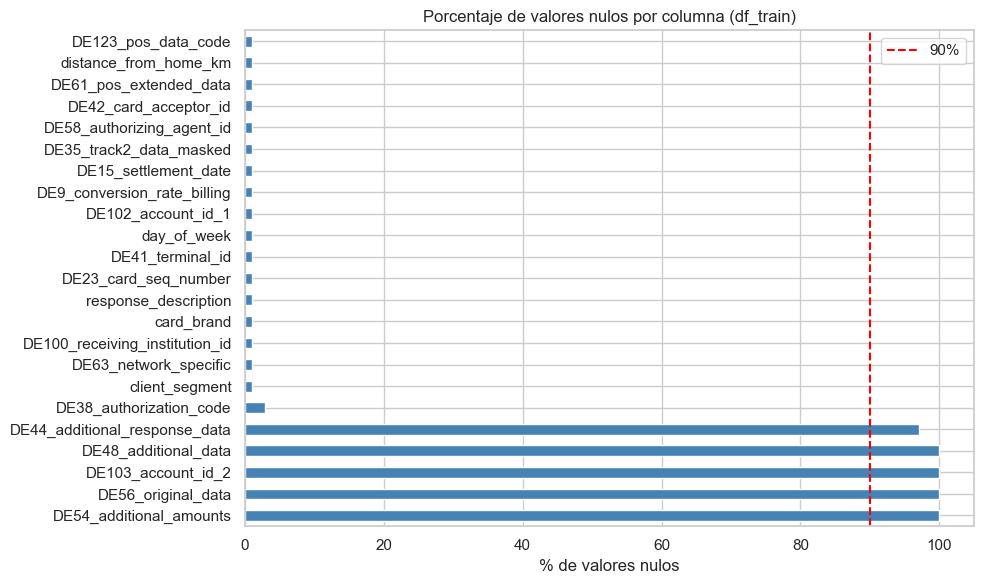

In [38]:
null_pct = df_train.isnull().mean() * 100
null_pct = null_pct.sort_values(ascending=False)
null_pct_nonzero = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
null_pct_nonzero.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de valores nulos por columna (df_train)")
ax.axvline(90, color="red", linestyle="--", label="90%")
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
print("\nColumnas con >90% nulos:")
print(null_pct[null_pct > 90].index.tolist())


Columnas con >90% nulos:
['DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2', 'DE48_additional_data', 'DE44_additional_response_data']


DE54 - additional_amounts
    Montos adicionales (ej: cashback, propina, balance de cuenta).
    **Indicaría que la que la mayoria de transacciones en este dataset no tiene montos adicionales**

DE56_original_data, DE103_account_id_2, DE48_additional_data, DE44_additional_response_data **no están descritos y son mayormente nulos**

In [44]:
duplicadas = bo.T[bo.T.duplicated()]
duplicadas

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,99963,99964,99965,99966,99967,99968,99969,99970,99971,99972,99973,99974,99975,99976,99977,99978,99979,99980,99981,99982,99983,99984,99985,99986,99987,99988,99989,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999,100000,100001,100002
bank_name,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,...,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP,BO-VIP
DE51_currency_code_billing,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,...,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68,68
DE54_additional_amounts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DE56_original_data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DE103_account_id_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Limpieza de Datos

Eliminación de columnas con >90% nulos

In [45]:
COLS_DROP_NULL = [
    "DE56_original_data",       
    "DE103_account_id_2",       
    "DE54_additional_amounts",  
    "DE48_additional_data",     
    "DE44_additional_response_data",
]

Elimino columas de identificación/trazabilidad que no aportarian a modelos

In [46]:
COLS_DROP_ID = [
    "transaction_id",
    "pan_masked",
    "pan_hash",
    "DE2_PAN",
    "DE11_STAN",
    "DE37_retrieval_reference_number",  # referencia interna
    "DE35_track2_data_masked",
    "DE43_card_acceptor_name_location", # texto libre
    "DE58_authorizing_agent_id",
    "DE63_network_specific",
    "DE56_original_data",
]


Columnas que derivan de otras o son redundantes

In [ ]:
COLS_DROP_REDUNDANT = [
    "DE12_local_time",# hour_local ya tiene la info, pero solo hora
    "DE13_local_date",# D/ tiene la misma info pero mas detallada
    "DE50_currency_code_settlement", # igual a DE49 en su mayoría
    "DE51_currency_code_billing", # igual a DE49 en su mayoría
    "bank_name", # redundante con bank_code
    "bank_country", # redundante con source_bank
    "DE15_settlement_date", # irrelevante para un entrenamiento fraude
]

In [54]:
final_list = list(set(COLS_DROP_NULL + COLS_DROP_ID + COLS_DROP_REDUNDANT))

def clean_drop(df):
    cols = [c for c in final_list if c in df.columns]
    return df.drop(columns=cols)

df_train = clean_drop(df_train)
df_test  = clean_drop(df_test)

print(df_train.shape)
print(df_test.shape)

(200003, 45)
(100000, 45)


In [55]:
before = len(df_train)
df_train = df_train.drop_duplicates()
print(f"Filas eliminadas por duplicado: {before - len(df_train)}")

Filas eliminadas por duplicado: 0


Parsear fechas


In [56]:
df_train["DE7_transmission_datetime"] = pd.to_datetime(
    df_train["DE7_transmission_datetime"], errors="coerce"
)
df_test["DE7_transmission_datetime"] = pd.to_datetime(
    df_test["DE7_transmission_datetime"], errors="coerce"
)

df_train["tx_month"]    = df_train["DE7_transmission_datetime"].dt.month
df_train["tx_day"]      = df_train["DE7_transmission_datetime"].dt.day
df_train["tx_hour"]     = df_train["DE7_transmission_datetime"].dt.hour
df_train["tx_weekday"]  = df_train["DE7_transmission_datetime"].dt.dayofweek

df_test["tx_month"]    = df_test["DE7_transmission_datetime"].dt.month
df_test["tx_day"]      = df_test["DE7_transmission_datetime"].dt.day
df_test["tx_hour"]     = df_test["DE7_transmission_datetime"].dt.hour
df_test["tx_weekday"]  = df_test["DE7_transmission_datetime"].dt.dayofweek

df_train.drop(columns=["DE7_transmission_datetime"], inplace=True)
df_test.drop(columns=["DE7_transmission_datetime"], inplace=True)

Relleno de nulos

In [ ]:
df_train.isna().sum()

bank_code                            0
bank_tier                            0
client_id                            0
client_segment                    2087
channel                              0
card_brand                        2052
MTI                                  0
DE3_processing_code                  0
DE4_amount_transaction               0
DE6_amount_cardholder_billing        0
DE9_conversion_rate_billing       2013
DE14_expiration_date                 0
DE18_merchant_category_code          0
DE19_acquirer_country_code           0
DE22_pos_entry_mode                  0
DE23_card_seq_number              2044
DE25_pos_condition_code              0
DE32_acquiring_institution_id        0
DE38_authorization_code           5768
DE39_response_code                   0
DE41_terminal_id                  2030
DE42_card_acceptor_id             1997
DE49_currency_code_transaction       0
DE52_pin_data_present                0
DE55_emv_data_present                0
DE60_pos_terminal_type   

In [58]:
# Numéricos a  mediana
num_cols = df_train.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    if df_train[col].isna().any():
        median_val = df_train[col].median()
        df_train[col].fillna(median_val, inplace=True)
        df_test[col].fillna(median_val, inplace=True)

# Categóricos a "UNKNOWN"
cat_cols = df_train.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    if df_train[col].isna().any():
        df_train[col].fillna("UNKNOWN", inplace=True)
        df_test[col].fillna("UNKNOWN", inplace=True)

print(f"Nulos restantes en train: {df_train.isnull().sum().sum()}")
print(f"Nulos restantes en test:  {df_test.isnull().sum().sum()}")

Nulos restantes en train: 32021
Nulos restantes en test:  141983


---
## 4. Análisis Exploratorio de Datos (EDA)

Tasa de fraude

In [60]:
print("Porcentaje de fraude por banco en train:")
print(df_train.groupby("source_bank")["is_fraud"].mean().map("{:.2%}".format))

Porcentaje de fraude por banco en train:
source_bank
BO_VIP        4.92%
BR_PRIVATE    3.21%
Name: is_fraud, dtype: str


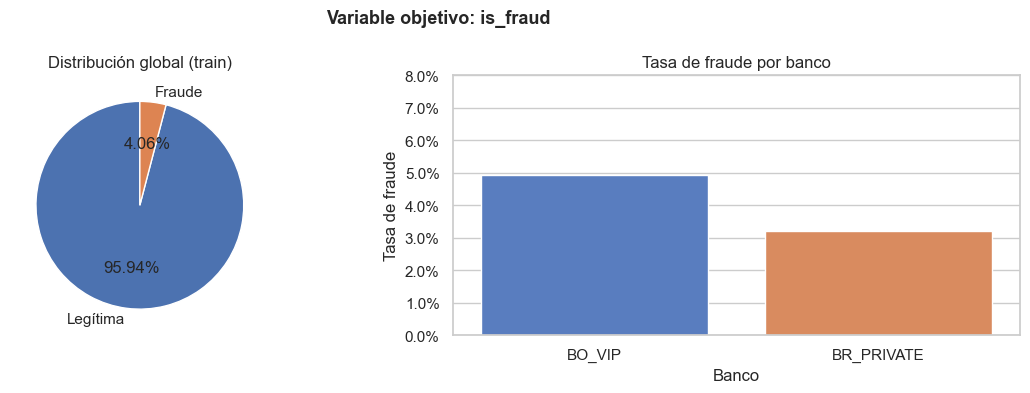

In [59]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Global
fraud_counts = df_train["is_fraud"].value_counts()
axes[0].pie(fraud_counts, labels=["Legítima", "Fraude"], autopct="%1.2f%%",
            colors=["#4c72b0", "#dd8452"], startangle=90)
axes[0].set_title("Distribución global (train)")

# Por banco
fraud_by_bank = df_train.groupby("source_bank")["is_fraud"].mean().reset_index()
fraud_by_bank.columns = ["Banco", "Tasa de fraude"]
sns.barplot(data=fraud_by_bank, x="Banco", y="Tasa de fraude", ax=axes[1], palette="muted")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title("Tasa de fraude por banco")
axes[1].set_ylim(0, 0.08)

plt.suptitle("Variable objetivo: is_fraud", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Distribución por cantidad de moneda

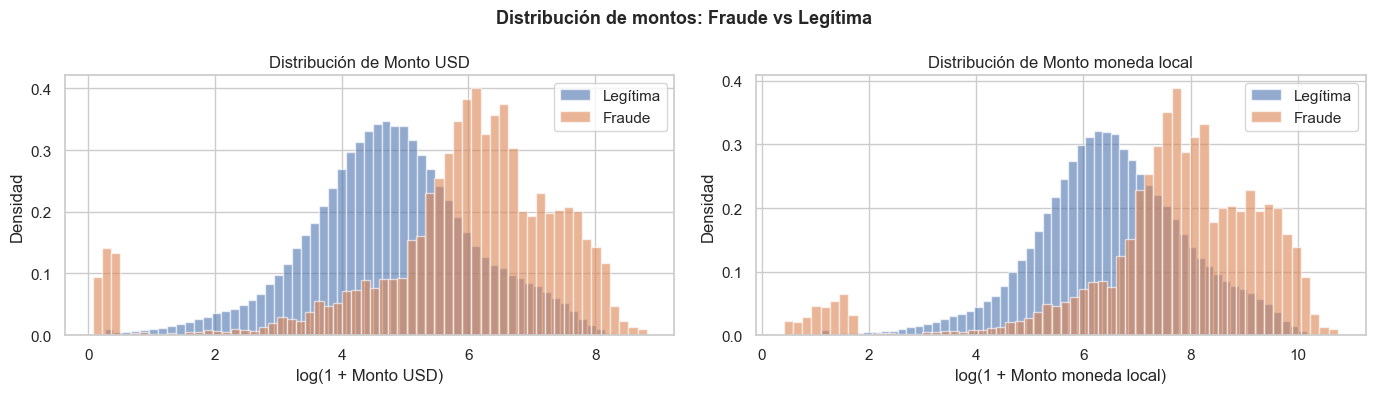

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes,
                           ["amount_usd", "amount_local"],
                           ["Monto USD", "Monto moneda local"]):
    for fraud_val, color, lbl in [(0, "#4c72b0", "Legítima"), (1, "#dd8452", "Fraude")]:
        subset = df_train[df_train["is_fraud"] == fraud_val][col]
        # logarithmic bin histogram
        data = subset[subset > 0]
        ax.hist(np.log1p(data), bins=60, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_xlabel(f"log(1 + {label})")
    ax.set_ylabel("Densidad")
    ax.set_title(f"Distribución de {label}")
    ax.legend()

plt.suptitle("Distribución de montos: Fraude vs Legítima", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [63]:
print("Estadísticas de amount_usd:")
print(df_train.groupby("is_fraud")["amount_usd"].describe().T)

Estadísticas de amount_usd:
is_fraud       False     True 
count    191879.0000 8124.0000
mean        263.7462  803.6317
std         424.9072  917.3485
min           0.2900    0.0700
25%          51.9500  211.8825
50%         114.8700  467.7500
75%         262.8100 1031.3525
max        6109.4700 6731.9000


Por hora del día

In [67]:
fraud_day = df_train.groupby("day_of_week")["is_fraud"].mean()
fraud_day

day_of_week
Fri   0.0413
Mon   0.0398
Sat   0.0434
Sun   0.0376
Thu   0.0393
Tue   0.0395
Wed   0.0431
Name: is_fraud, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Por hora
fraud_hour = df_train.groupby("hour_local")["is_fraud"].mean()
axes[0].bar(fraud_hour.index, fraud_hour.values, color="#4c72b0")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel("Hora local")
axes[0].set_ylabel("Tasa de fraude")
axes[0].set_title("Tasa de fraude por hora del día")

# Por día de la semana — day_of_week son abreviaciones de texto ("Mon", "Tue", ...)
DAY_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
fraud_day = (df_train.groupby("day_of_week")["is_fraud"]
             .mean()
             .reindex(DAY_ORDER)   # orden lunes → domingo
             .dropna())

axes[1].bar(range(len(fraud_day)), fraud_day.values, color="#dd8452",
            tick_label=fraud_day.index.tolist())
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_xlabel("Día de la semana")
axes[1].set_ylabel("Tasa de fraude")
axes[1].set_title("Tasa de fraude por día de la semana")

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------------
# 4.4  Variables categóricas clave vs is_fraud
# -----------------------------------------------------------------
cat_features = [
    ("channel",          "Canal de transacción"),
    ("DE22_pos_entry_mode", "POS Entry Mode"),
    ("DE25_pos_condition_code", "POS Condition Code"),
    ("is_international", "Internacional"),
    ("DE52_pin_data_present", "PIN usado"),
    ("DE55_emv_data_present", "EMV/Chip usado"),
    ("card_brand",       "Marca de tarjeta"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(cat_features):
    if col not in df_train.columns:
        axes[i].set_visible(False)
        continue
    fraud_rate = df_train.groupby(col)["is_fraud"].mean().sort_values(ascending=False)
    # mantener top-10 categorías para legibilidad
    fraud_rate = fraud_rate.head(10)
    axes[i].bar(range(len(fraud_rate)), fraud_rate.values, color="#4c72b0")
    axes[i].set_xticks(range(len(fraud_rate)))
    axes[i].set_xticklabels(fraud_rate.index.astype(str), rotation=45, ha="right", fontsize=8)
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].set_title(title, fontsize=9)
    axes[i].set_ylabel("Tasa fraude")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de fraude por variable categórica", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------------
# 4.5  Top MCC por tasa de fraude
# -----------------------------------------------------------------
mcc_fraud = (df_train.groupby("DE18_merchant_category_code")
             .agg(n_tx=("is_fraud", "count"), fraud_rate=("is_fraud", "mean"))
             .query("n_tx >= 100")  # al menos 100 transacciones
             .sort_values("fraud_rate", ascending=False)
             .head(15)
             .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mcc_fraud["DE18_merchant_category_code"].astype(str),
               mcc_fraud["fraud_rate"], color="#dd8452")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Tasa de fraude")
ax.set_title("Top 15 MCC con mayor tasa de fraude (mín 100 tx)")
ax.invert_yaxis()

for bar, n in zip(bars, mcc_fraud["n_tx"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"n={n:,}", va="center", fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------------
# 4.6  Correlación de variables numéricas con is_fraud
# -----------------------------------------------------------------
num_cols_train = df_train.select_dtypes(include=np.number).columns.tolist()
corr_with_fraud = (df_train[num_cols_train]
                   .corr()["is_fraud"]
                   .drop("is_fraud")
                   .sort_values(key=abs, ascending=False)
                   .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#dd8452" if v > 0 else "#4c72b0" for v in corr_with_fraud.values]
ax.barh(corr_with_fraud.index, corr_with_fraud.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Pearson con is_fraud")
ax.set_title("Top 20 variables numéricas correlacionadas con fraude")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Ingeniería de Características (Feature Engineering)

In [ ]:
def feature_engineering(df, client_stats=None, fit=True):
    df = df.copy()

    # --- 5.1 Features temporales ---
    df["is_weekend"]      = df["day_of_week"].isin(["Saturday", "Sunday", 5, 6]).astype(int)
    df["is_night"]        = df["hour_local"].between(0, 5).astype(int)
    df["hour_sin"]        = np.sin(2 * np.pi * df["hour_local"] / 24)
    df["hour_cos"]        = np.cos(2 * np.pi * df["hour_local"] / 24)

    # --- 5.2 Features de canal ---
    ecommerce_modes = ["081", "810", "81", 81]
    df["is_online"] = df["DE22_pos_entry_mode"].isin(ecommerce_modes).astype(int)
    df["is_contactless"] = df["DE22_pos_entry_mode"].isin(["070", "710", "70", 70]).astype(int)
    df["is_manual_entry"] = df["DE22_pos_entry_mode"].isin(["010", "10", 10]).astype(int)
    df["is_fallback"] = df["DE22_pos_entry_mode"].isin(["080", "80", 80]).astype(int)

    # Card not present
    cnp_modes = ["081", "810", "81", 81, "010", "10", 10]
    df["is_cnp"] = (
        df["DE22_pos_entry_mode"].isin(cnp_modes) |
        df["DE25_pos_condition_code"].isin(["01", "08", "59", 1, 8, 59])
    ).astype(int)

    # --- 5.3 Ratio monto vs baseline del cliente ---
    df["amount_usd_log"] = np.log1p(df["amount_usd"])
    df["client_baseline_amount_log"] = np.log1p(df["client_baseline_amount"])
    df["amount_ratio_baseline"] = df["amount_usd"] / (df["client_baseline_amount"] + 1)
    df["amount_above_baseline"] = (df["amount_usd"] > df["client_baseline_amount"]).astype(int)

    # --- 5.4 Features de ubicación ---
    df["is_international"] = df["is_international"].astype(int)
    df["distance_log"] = np.log1p(df["distance_from_home_km"])
    df["high_distance"] = (df["distance_from_home_km"] > 500).astype(int)

    # --- 5.5 Tasa de conversión (diferente de 1 puede indicar operación internacional) ---
    df["has_conversion"] = (df["DE9_conversion_rate_billing"] != 1.0).astype(int)

    # --- 5.6 Features de comportamiento por cliente (calculadas sobre train) ---
    if fit:
        client_stats = (df.groupby("client_id")
                        .agg(
                            client_tx_count=("amount_usd", "count"),
                            client_avg_amount=("amount_usd", "mean"),
                            client_std_amount=("amount_usd", "std"),
                            client_fraud_rate=("is_fraud", "mean") if "is_fraud" in df.columns else ("amount_usd", "count"),
                        )
                        .reset_index())
        if "is_fraud" not in df.columns:
            client_stats.rename(columns={"client_fraud_rate": "client_tx_count2"}, inplace=True)
    
    df = df.merge(client_stats, on="client_id", how="left")
    df["client_std_amount"] = df["client_std_amount"].fillna(0)
    # z-score del monto respecto al historial del cliente
    df["amount_zscore"] = (
        (df["amount_usd"] - df["client_avg_amount"]) / (df["client_std_amount"] + 1e-6)
    )

    # --- 5.7 MCC agrupado en categorías de riesgo ---
    HIGH_RISK_MCC = {6011, 6051, 7995, 5912, 4829, 6010}  # ATMs, casinos, farmacias, wire transfers
    df["mcc_high_risk"] = df["DE18_merchant_category_code"].isin(HIGH_RISK_MCC).astype(int)

    # --- 5.8 Respuesta del sistema ---
    df["tx_declined"] = (df["DE39_response_code"] != "00").astype(int)
    df["approved_int"] = df["approved"].astype(int) if df["approved"].dtype != object else \
                         (df["approved"].str.upper() == "TRUE").astype(int)

    return df, client_stats

df_train, client_stats_train = feature_engineering(df_train, fit=True)
# Para test usamos stats aprendidas de train
df_test, _ = feature_engineering(df_test, client_stats=client_stats_train, fit=False)

print(f"Train shape tras feature engineering: {df_train.shape}")
print(f"Test  shape tras feature engineering: {df_test.shape}")

In [ ]:
# -----------------------------------------------------------------
# 5.9  Codificación de variables categóricas
# -----------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

CAT_ENCODE = [
    "bank_tier", "client_segment", "channel", "card_brand",
    "DE3_processing_code", "DE22_pos_entry_mode", "DE25_pos_condition_code",
    "DE39_response_code", "DE49_currency_code_transaction", "currency_tx_alpha",
    "MTI", "source_bank",
]

label_encoders = {}
for col in CAT_ENCODE:
    if col in df_train.columns:
        le = LabelEncoder()
        df_train[col + "_enc"] = le.fit_transform(df_train[col].astype(str))
        # Para test: categorías desconocidas → -1
        mapping = {v: i for i, v in enumerate(le.classes_)}
        df_test[col + "_enc"] = df_test[col].astype(str).map(mapping).fillna(-1).astype(int)
        label_encoders[col] = le

print("Columnas codificadas:", [c for c in CAT_ENCODE if c in df_train.columns])

---
## 6. Construcción del Dataset Final para Entrenamiento

In [ ]:
# -----------------------------------------------------------------
# Features seleccionadas para el modelo
# -----------------------------------------------------------------
FEATURES = [
    # Temporales
    "hour_local", "hour_sin", "hour_cos", "is_weekend", "is_night",
    "tx_month", "tx_weekday",
    # Montos
    "amount_usd_log", "amount_local", "client_baseline_amount_log",
    "amount_ratio_baseline", "amount_above_baseline", "amount_zscore",
    # Canal / POS
    "is_online", "is_contactless", "is_manual_entry", "is_fallback", "is_cnp",
    "DE52_pin_data_present", "DE55_emv_data_present",
    # Ubicación
    "is_international", "distance_log", "high_distance",
    # Comportamiento cliente
    "client_tx_count", "client_avg_amount", "client_std_amount",
    # MCC
    "mcc_high_risk",
    # Conversión / respuesta
    "has_conversion", "tx_declined", "approved_int",
    # Categóricas codificadas
    "bank_tier_enc", "client_segment_enc", "channel_enc", "card_brand_enc",
    "DE3_processing_code_enc", "DE22_pos_entry_mode_enc",
    "DE25_pos_condition_code_enc", "DE39_response_code_enc",
    "DE49_currency_code_transaction_enc", "MTI_enc", "source_bank_enc",
]

# Filtrar solo las que existen
FEATURES = [f for f in FEATURES if f in df_train.columns]
TARGET = "is_fraud"

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)
X_test  = df_test[FEATURES]

print(f"X_train: {X_train.shape}  |  y_train distribución: {y_train.value_counts().to_dict()}")
print(f"X_test:  {X_test.shape}")
print(f"\nFeatures seleccionadas ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  - {f}")

In [ ]:
# -----------------------------------------------------------------
# Importancia de features con RandomForest (referencia rápida)
# -----------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                             class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(25).plot(kind="barh", ax=ax, color="#4c72b0")
ax.invert_yaxis()
ax.set_title("Importancia de features (Random Forest — top 25)")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
print(importances.head(10).to_string())

In [ ]:
# -----------------------------------------------------------------
# Métricas de validación del RF baseline
# -----------------------------------------------------------------
from sklearn.metrics import (classification_report, roc_auc_score,
                              ConfusionMatrixDisplay, RocCurveDisplay)

y_pred  = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)[:, 1]

print("=== Classification Report (validación 20%) ===")
print(classification_report(y_val, y_pred, target_names=["Legítima", "Fraude"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred,
    display_labels=["Legítima", "Fraude"], ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión")

RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].set_title(f"Curva ROC (AUC = {roc_auc_score(y_val, y_proba):.3f})")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------------
# Guardar datasets finales
# -----------------------------------------------------------------
X_train.assign(is_fraud=y_train).to_csv("dataset_train_final.csv", index=False)
X_test.to_csv("dataset_test_final.csv", index=False)

print("Archivos guardados:")
print(f"  dataset_train_final.csv  → {X_train.shape[0]:,} filas, {X_train.shape[1]} features + target")
print(f"  dataset_test_final.csv   → {X_test.shape[0]:,} filas, {X_test.shape[1]} features (sin target)")
print(f"\nResumen del dataset de entrenamiento:")
print(f"  Transacciones legítimas: {(y_train==0).sum():,}  ({(y_train==0).mean():.2%})")
print(f"  Transacciones fraudulentas: {(y_train==1).sum():,}  ({(y_train==1).mean():.2%})")
print(f"  Total features: {len(FEATURES)}")